In [3]:
import os
import warnings

warnings.filterwarnings('ignore')
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"     # Suppress INFO, WARNING, and ERROR logs from TF/absl

import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.preprocessing import FunctionTransformer
from tensorflow.keras.layers import RandomRotation, RandomTranslation, RandomZoom, Conv2D, MaxPooling2D, Dropout, Dense, Flatten  # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from sklearn.model_selection import train_test_split
from scikeras.wrappers import KerasClassifier 
from tensorflow.keras.optimizers import Adam # type: ignore
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

tf.get_logger().setLevel('ERROR')            # Belt-and-suspenders: also mute TF's own logger

In [4]:
data = pd.read_csv("C:\\Users\\sulem\\OneDrive\\Desktop\\Codes\\ML\\Datasets\\MNIST.csv")
# print(data.head())
# print(data.corr()["label"])

x = data.drop("label", axis = 1)
y = data["label"]

trainx, testx, trainy, testy = train_test_split(x,y, test_size=0.3, random_state=33)

def FeatureTransfrmation(data):

    data = data.values / 255
    data = data.reshape(-1, 28, 28, 1)  # flat pixels -> image format for Conv2D
    return data

f = FunctionTransformer(FeatureTransfrmation)

In [5]:
def build_model(meta):

    input_shape = meta["X_shape_"][1:]

    m = Sequential()

    m.add(RandomRotation(0.03, input_shape=input_shape))   # ~11 degrees -- kept small so a 6 doesn't drift toward a 9
    m.add(RandomTranslation(0.1, 0.1))
    m.add(RandomZoom(0.1))

    m.add(Conv2D(128, kernel_size=(3,3), activation="relu"))
    m.add(Conv2D(64, kernel_size=(3,3), activation="relu"))
    m.add(MaxPooling2D(pool_size=(2,2)))
    m.add(Dropout(0.3))

    m.add(Flatten())

    m.add(Dense(256, activation="relu"))
    m.add(Dropout(0.3)) 
    m.add(Dense(128, activation="relu"))
    m.add(Dropout(0.3))   
    m.add(Dense(10, activation="softmax"))

    m.compile(loss="sparse_categorical_crossentropy",optimizer=Adam(learning_rate=0.001), metrics=["accuracy"])

    return m

In [6]:
m = KerasClassifier(model=build_model, epochs=25, batch_size=33, verbose=1, validation_split=0.3)

pipe = make_pipeline(f,m)
pipe.fit(trainx,trainy)

Epoch 1/25
624/624 ━━━━━━━━━━━━━━━━━━━━ 99s 153ms/step - accuracy: 0.8232 - loss: 0.5518 - val_accuracy: 0.9712 - val_loss: 0.0900
Epoch 2/25
624/624 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.9340 - loss: 0.2185 - val_accuracy: 0.9827 - val_loss: 0.0594
Epoch 3/25
624/624 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.9502 - loss: 0.1703 - val_accuracy: 0.9846 - val_loss: 0.0485
Epoch 4/25
624/624 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.9576 - loss: 0.1444 - val_accuracy: 0.9872 - val_loss: 0.0435
Epoch 5/25
624/624 ━━━━━━━━━━━━━━━━━━━━ 96s 153ms/step - accuracy: 0.9637 - loss: 0.1246 - val_accuracy: 0.9864 - val_loss: 0.0493
Epoch 6/25
624/624 ━━━━━━━━━━━━━━━━━━━━ 96s 154ms/step - accuracy: 0.9682 - loss: 0.1056 - val_accuracy: 0.9825 - val_loss: 0.0684
Epoch 7/25
624/624 ━━━━━━━━━━━━━━━━━━━━ 95s 153ms/step - accuracy: 0.9683 - loss: 0.1045 - val_accuracy: 0.9876 - val_loss: 0.0403
Epoch 8/25
624/624 ━━━━━━━━━━━━━━━━━━━━ 95s 152ms/step - accuracy: 0.9701 - loss: 0

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function FeatureTransfrmation at 0x00000249277F5DA0>)),
                ('kerasclassifier',
                 KerasClassifier(batch_size=33, epochs=25, model=<function build_model at 0x0000024919A8D6C0>, validation_split=0.3))])

In [7]:
predy = pipe.predict(testx) 
print("Accuracy:", accuracy_score(testy, predy))

382/382 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step
Accuracy: 0.9884126984126984


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


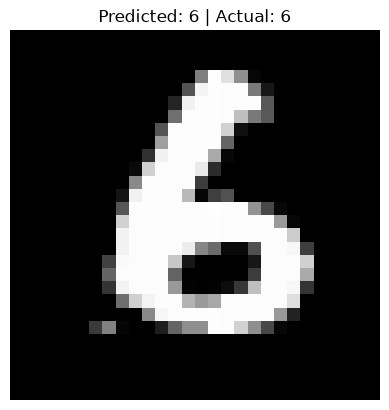

In [9]:
import matplotlib.pyplot as plt

sample_x = testx.iloc[[28]]
sample_y = testy.iloc[28]

pred = pipe.predict(sample_x)

image = sample_x.values.reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title("Predicted: {} | Actual: {}".format(pred[0], sample_y))
plt.axis("off")
plt.show()